In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Fetch the California housing dataset as an alternative to the deprecated Boston dataset
boston = fetch_openml(name='boston',version=1,as_frame=True)
df = boston.frame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
df['price']=boston.target
df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,36.2


importing the Boston House Price Dataset

divding the dataset into dependent anf independent

In [ ]:
feature_columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X = df[feature_columns]
X = X.astype(float)
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [ ]:
y = df['price']
y = y.astype(float)
y.head()

,price
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


split the data into training data and test data

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)
print(X.shape,X_train.shape,X_test.shape)

(506, 13) (404, 13) (102, 13)


In [ ]:
print(X_train.head(),X_test.head())

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
321  0.18159   0.0   7.38   0.0  0.493  6.376  54.3  4.5404  5.0  287.0   
37   0.08014   0.0   5.96   0.0  0.499  5.850  41.5  3.9342  5.0  279.0   
286  0.01965  80.0   1.76   0.0  0.385  6.230  31.5  9.0892  1.0  241.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
25   0.84054   0.0   8.14   0.0  0.538  5.599  85.7  4.4546  4.0  307.0   

     PTRATIO       B  LSTAT  
321     19.6  396.90   6.87  
37      19.2  396.90   8.77  
286     18.2  341.60  12.93  
2       17.8  392.83   4.03  
25      21.0  303.42  16.51            CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS   RAD    TAX  \
463   5.82115   0.0  18.10   0.0  0.713  6.513  89.9  2.8016  24.0  666.0   
152   1.12658   0.0  19.58   1.0  0.871  5.012  88.0  1.6102   5.0  403.0   
291   0.07886  80.0   4.95   0.0  0.411  7.148  27.7  5.1167   4.0  245.0   
183   0.10008   0.0   2.46   0.0  0.488  6.563  95.6  2.8470 

linear Regression

In [ ]:
lin_reg=LinearRegression()
lin_reg.fit(X_train,y_train)

# Ensure X_test contains only numeric types and handle any potential NaNs
X_test_processed = X_test.apply(pd.to_numeric, errors='coerce')

# Fill any NaNs that might have been introduced during coercion with the mean of the column
# This is a simple imputation strategy, more advanced methods can be used if needed.
if X_test_processed.isnull().any().any():
    X_test_processed = X_test_processed.fillna(X_test_processed.mean())

y_predict=lin_reg.predict(X_test_processed)
y_predict

array([23.01506153, 21.2115869 , 33.71590384, 31.56542369,  3.1826268 ,
        3.15381954, 27.40305304, 22.2126176 , 14.86506114, 21.34105453,
       30.95942941, 26.70065029, 21.12624382, 18.37282564, 17.64315354,
       25.38194186, 24.42970445, 13.36957057,  8.66686786, 18.57490534,
       21.73966467, 20.34270529, 36.5461105 , 20.59627495, 19.87979627,
       15.75766967, 37.11632999, 34.85897895, 30.83458635, 23.23441285,
       18.68278505, 20.749546  , 31.84560076, 30.20214207, 13.3861702 ,
       15.87078398, 13.70766096, 23.74163998, 25.95135088, 23.18325878,
       28.99906539, 12.50341936, 31.08347911,  6.39401895, 23.71801218,
       20.61523929, 33.15362417, 19.21862493, 35.89603081,  0.82365329,
       31.90288611, 31.69640543,  6.58849712, 34.62762996, 20.41162545,
       19.69277608, 19.53445865, 18.58689088, 15.81420496, 22.98764309,
       19.65947045, 16.36377019, 18.48783369, 32.76568172, 35.49022568,
       24.58349631, 41.5854766 , 32.94818456, 14.60990256, 27.43

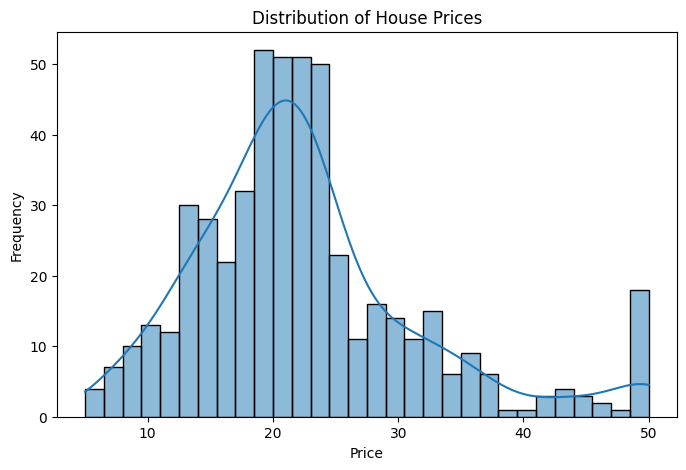

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_predict)

# Create a list to store the results
results = [
    {"Model": "Linear Regression", "MAE": mae, "RMSE": rmse, "R2 Score": r2}
]

comparison_df = pd.DataFrame(
    results, columns=["Model", "MAE", "RMSE", "R2 Score"]
)

print(comparison_df)

               Model       MAE     RMSE  R2 Score
0  Linear Regression  3.113044  4.30063  0.778921


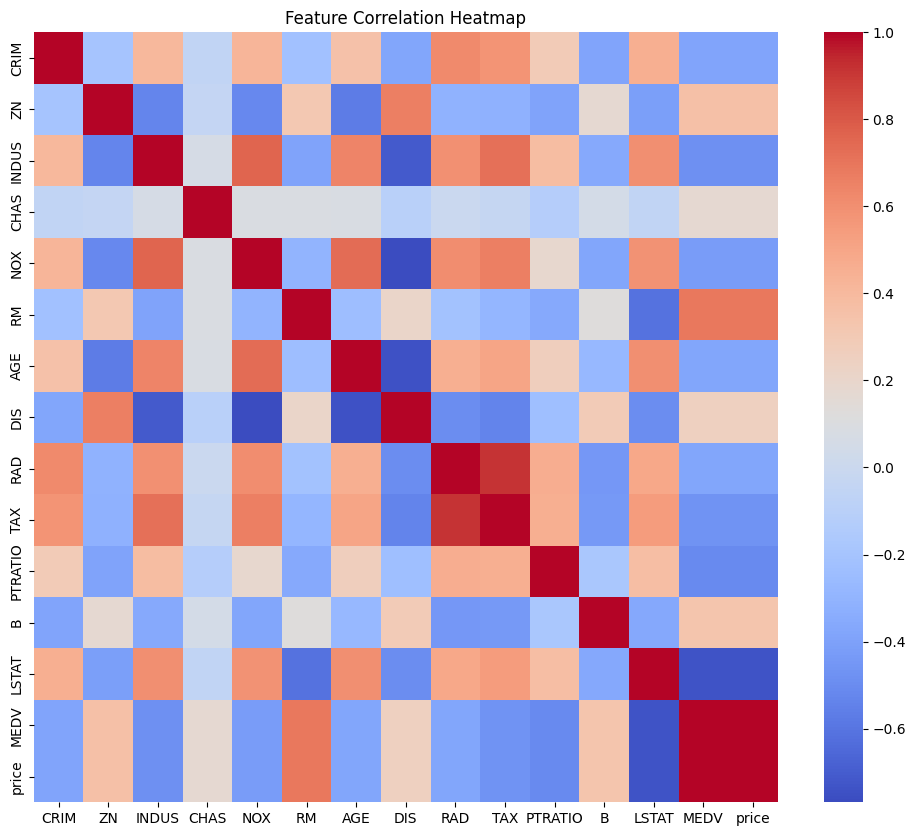

In [ ]:
plt.figure(figsize=(12,10))
correlation = df.corr()
sns.heatmap(correlation, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

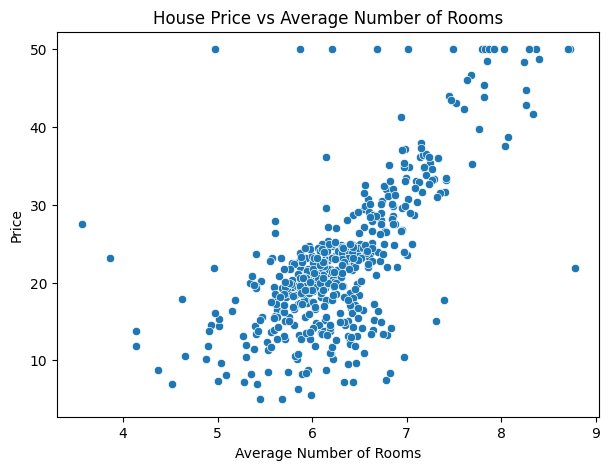

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['RM'], y=df['price'])
plt.title('House Price vs Average Number of Rooms')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Price')
plt.show()

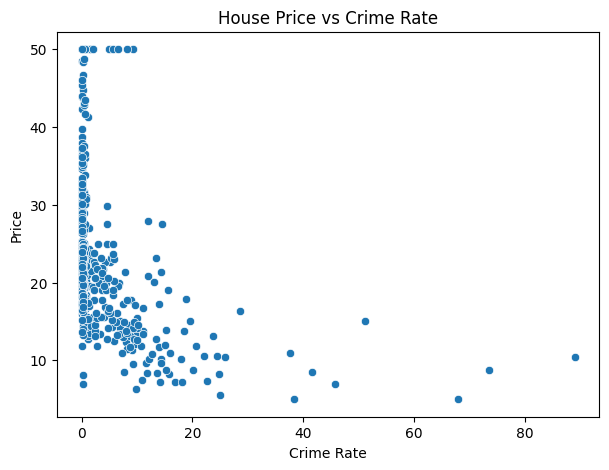

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['CRIM'], y=df['price'])
plt.title('House Price vs Crime Rate')
plt.xlabel('Crime Rate')
plt.ylabel('Price')
plt.show()

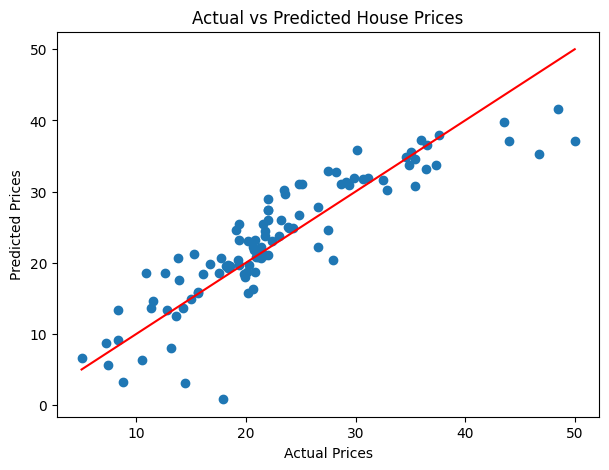

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_predict)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color='red')
plt.show()

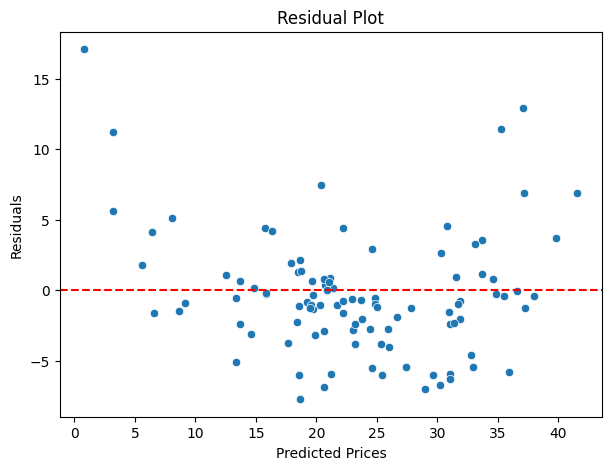

In [ ]:
residuals = y_test - y_predict

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_predict, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

linear Ridge & Lasso REgression


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error,r2_score

In [ ]:
boston = fetch_openml(name='boston',version=1,as_frame=True)
df = boston.frame
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
X=df.drop("MEDV",axis=1)
y=df["MEDV"]


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
ir=LinearRegression()
ir.fit(X_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score

# Before predicting, ensure X_test is numeric to avoid TypeError
# The original df columns might not be float by default from fetch_openml
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce')

# Fill any NaNs that might arise from coercion (e.g., if there were actual non-numeric strings)
# Using mean for simplicity, a more sophisticated imputation might be needed for real projects.
if X_test_numeric.isnull().any().any():
    X_test_numeric = X_test_numeric.fillna(X_test_numeric.mean())

y_pred_lr=ir.predict(X_test_numeric)
print("linear Regression")
print("MSE:",mean_squared_error(y_test,y_pred_lr))
print("R2Score",r2_score(y_test,y_pred_lr))

linear Regression
MSE: 24.291119474973478
R2Score 0.6687594935356326


In [ ]:
lr_coeff=pd.Series(ir.coef_,index=X.columns)
lr_coeff

,0
CRIM,-0.113056
ZN,0.030110
INDUS,0.040381
CHAS,2.784438
NOX,-17.202633
RM,4.438835
AGE,-0.006296
DIS,-1.447865
RAD,0.262430
TAX,-0.010647
